# 06 — Comparação de Modelos Fit / No-Fit

Este notebook evolui o **modelo baseline** (Regressão Logística + TF-IDF sobre o
texto concatenado) do classificador de aderência currículo ↔ vaga e **compara
vários modelos** sobre o dataset [Resume-JD-Match](https://huggingface.co/datasets/facehuggerapoorv/resume-jd-match).

**O que é avaliado**

1. *Por que o baseline trava em ~0,60 de acurácia* — o texto concatenado mistura
   os termos da vaga e do currículo num único saco de palavras, descartando o
   sinal de **casamento** entre os dois lados.
2. *Engenharia de atributos* (`src/features.py`) — separa vaga e currículo e cria
   features de interação (similaridade, sobreposição de termos, SVD da interação).
3. *Comparação de modelos* (`src/training.py`) — Regressão Logística, SVM Linear,
   Complement Naive Bayes, Random Forest e Gradient Boosting, em acurácia,
   precisão, recall, F1 e ROC-AUC.
4. *Calibração de limiar* e *inferência* com `predict_fit`.


In [1]:
import os, sys
from pathlib import Path

raiz_projeto = Path(os.getcwd()).resolve()
if raiz_projeto.name == "notebooks":
    raiz_projeto = raiz_projeto.parent
if str(raiz_projeto) not in sys.path:
    sys.path.append(str(raiz_projeto))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, roc_curve, RocCurveDisplay,
                             classification_report)

from src.data_loader import carregar_resume_jd_match
from src.features import JobMatchFeaturizer
from src.training import (MAPA_LABELS, SEMENTE, _modelos_baseline, _modelos_match,
                          _todos_estimadores, _metricas, _scores_positivos,
                          _melhor_limiar)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print("Ambiente pronto.")


Ambiente pronto.


## 1. Carregar e preparar os dados

Binarizamos o rótulo (No Fit = 0; Potential/Good Fit = 1) e mantemos o split original train/test do Hugging Face.

In [2]:
df = carregar_resume_jd_match()
df["y"] = df["label"].map(MAPA_LABELS)

treino = df[df["split"] == "train"].copy()
teste = df[df["split"] == "test"].copy()
y_tr, y_te = treino["y"].to_numpy(), teste["y"].to_numpy()

print(f"Treino: {len(treino)} | Teste: {len(teste)}")
print(f"Proporção de 'Fit' -> treino: {y_tr.mean():.1%} | teste: {y_te.mean():.1%}")
display(df.groupby(["split", "label"]).size().unstack(fill_value=0))


Treino: 6241 | Teste: 1759
Proporção de 'Fit' -> treino: 49.6% | teste: 51.3%


label,Good Fit,No Fit,Potential Fit
split,,,
test,458,857,444
train,1542,3143,1556


## 2. Por que o baseline trava em ~0,60

Cada exemplo vem como um único texto:

> `For the given job description << <vaga> >> <currículo>`

O baseline joga tudo isso num **único TF-IDF**. O modelo vê *quais* palavras
aparecem, mas não consegue saber se elas aparecem **na vaga, no currículo ou em
ambos** — que é exatamente o que define um match. Resultado: acurácia mal passa
do acaso.

In [3]:
vec_baseline = TfidfVectorizer(max_features=5000, stop_words="english")
Xb_tr = vec_baseline.fit_transform(treino["text"])
Xb_te = vec_baseline.transform(teste["text"])

base_lr = LogisticRegression(max_iter=1000, random_state=SEMENTE).fit(Xb_tr, y_tr)
base_scores = base_lr.predict_proba(Xb_te)[:, 1]
base_pred = base_lr.predict(Xb_te)

print("BASELINE — LogReg + TF-IDF (texto concatenado)")
for k, v in _metricas(y_te, base_pred, base_scores).items():
    print(f"  {k:9s}: {v:.4f}")


BASELINE — LogReg + TF-IDF (texto concatenado)
  acuracia : 0.6066
  precisao : 0.6319
  recall   : 0.5576
  f1       : 0.5925
  roc_auc  : 0.6613


## 3. Engenharia de atributos de casamento

`JobMatchFeaturizer` (`src/features.py`) separa vaga e currículo e gera, com
vocabulário **compartilhado**, atributos que medem o quanto o currículo cobre a
vaga: similaridade do cosseno, nº de termos em comum, Jaccard, cobertura, além de
representações latentes (SVD) do texto e da matriz de interação termo-a-termo.

In [4]:
featurizer = JobMatchFeaturizer(random_state=SEMENTE)
Xm_tr = featurizer.fit_transform(treino["text"])
Xm_te = featurizer.transform(teste["text"])
print(f"Dimensão das features de match: {Xm_tr.shape[1]}")

# Correlação das features interpretáveis com o rótulo (no treino)
escalares = [c for c in featurizer.feature_names_ if not c.startswith("svd_")]
corr = (pd.DataFrame(Xm_tr[:, :len(escalares)], columns=escalares)
          .assign(y=y_tr).corr()["y"].drop("y").sort_values(key=np.abs, ascending=False))
print("\nCorrelação com 'Fit' (features interpretáveis):")
display(corr.to_frame("correlação"))


Dimensão das features de match: 168

Correlação com 'Fit' (features interpretáveis):


,correlação
cos_vaga_cv,0.2332
jaccard,0.1907
cobertura_vaga,0.1577
termos_em_comum,0.1223
log_tamanho_vaga,0.0150
n_termos_cv,0.0137
log_tamanho_cv,-0.0014
n_termos_vaga,-0.0007


## 4. Comparação de modelos

Treinamos cada modelo no conjunto adequado de atributos e avaliamos no teste. Os modelos do grupo **match** usam as features de casamento; os do grupo **baseline** usam o TF-IDF concatenado.

In [5]:
grupos = {
    "baseline": (_modelos_baseline(), Xb_tr, Xb_te),
    "match":    (_modelos_match(),    Xm_tr, Xm_te),
}

linhas, ajustados, predicoes = [], {}, {}
for grupo, (modelos, X_tr, X_te) in grupos.items():
    for nome, estimador in modelos.items():
        modelo = clone(estimador).fit(X_tr, y_tr)
        scores = _scores_positivos(modelo, X_te)
        y_pred = modelo.predict(X_te)
        m = _metricas(y_te, y_pred, scores)
        m.update(modelo=nome, grupo=grupo)
        linhas.append(m)
        ajustados[nome] = modelo
        predicoes[nome] = (y_pred, scores)

comparacao = (pd.DataFrame(linhas)
              .set_index("modelo")
              [["grupo", "acuracia", "precisao", "recall", "f1", "roc_auc"]]
              .sort_values("f1", ascending=False))
display(comparacao.style.background_gradient(cmap="Greens", subset=["f1", "roc_auc"]))

nome_melhor = comparacao.index[0]
tipo_melhor = comparacao.iloc[0]["grupo"]
print(f"Melhor modelo (por F1): {nome_melhor}")


,grupo,acuracia,precisao,recall,f1,roc_auc
modelo,,,,,,
HistGradientBoosting (features match),match,0.673678,0.677489,0.694013,0.685652,0.720410
LogReg (features match),match,0.649233,0.638215,0.729490,0.680807,0.696112
RandomForest (features match),match,0.664014,0.665250,0.694013,0.679327,0.717691
LogReg (TF-IDF baseline),baseline,0.606595,0.631910,0.557650,0.592462,0.661323
ComplementNB (TF-IDF),baseline,0.575895,0.584052,0.600887,0.592350,0.613195
LinearSVM (TF-IDF),baseline,0.595793,0.682600,0.395787,0.501053,0.655980


Melhor modelo (por F1): HistGradientBoosting (features match)


## 5. Visualizações

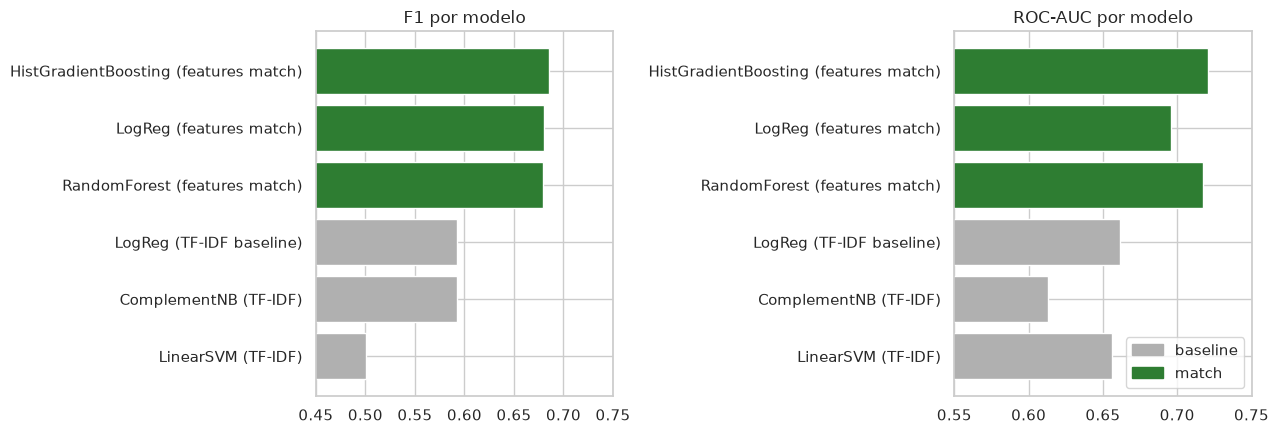

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ordem = comparacao.sort_values("f1").index
cores = comparacao.loc[ordem, "grupo"].map({"baseline": "#b0b0b0", "match": "#2e7d32"})
ax[0].barh(ordem, comparacao.loc[ordem, "f1"], color=cores)
ax[0].set_title("F1 por modelo"); ax[0].set_xlim(0.45, 0.75)
ax[1].barh(ordem, comparacao.loc[ordem, "roc_auc"], color=cores)
ax[1].set_title("ROC-AUC por modelo"); ax[1].set_xlim(0.55, 0.75)
from matplotlib.patches import Patch
ax[1].legend(handles=[Patch(color="#b0b0b0", label="baseline"),
                      Patch(color="#2e7d32", label="match")], loc="lower right")
plt.tight_layout(); plt.show()


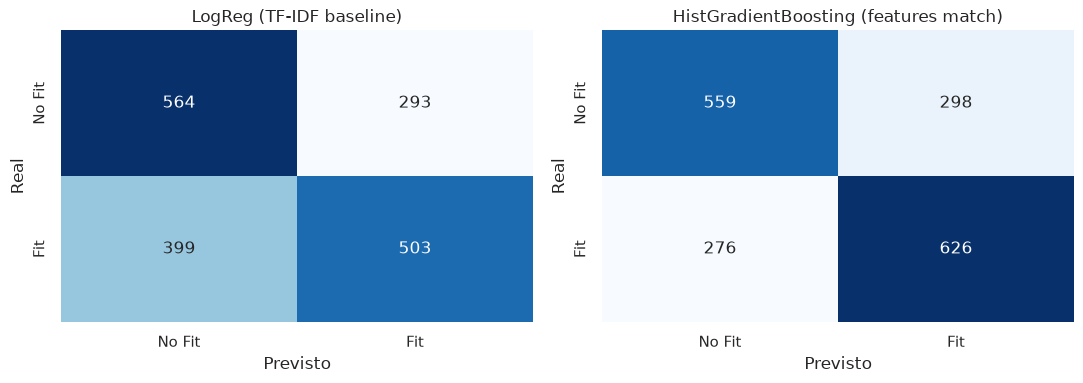

In [7]:
# Matrizes de confusão: baseline vs melhor modelo
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for eixo, nome in zip(ax, ["LogReg (TF-IDF baseline)", nome_melhor]):
    cm = confusion_matrix(y_te, predicoes[nome][0])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=eixo,
                xticklabels=["No Fit", "Fit"], yticklabels=["No Fit", "Fit"])
    eixo.set_title(nome); eixo.set_xlabel("Previsto"); eixo.set_ylabel("Real")
plt.tight_layout(); plt.show()


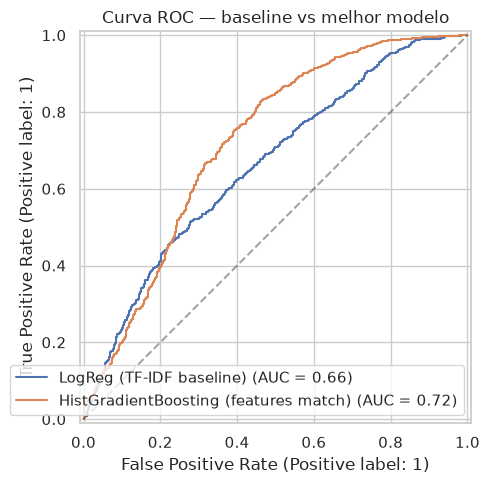

In [8]:
# Curvas ROC: baseline vs melhor modelo
fig, eixo = plt.subplots(figsize=(6, 5))
for nome in ["LogReg (TF-IDF baseline)", nome_melhor]:
    RocCurveDisplay.from_predictions(y_te, predicoes[nome][1], name=nome, ax=eixo)
eixo.plot([0, 1], [0, 1], "k--", alpha=0.4)
eixo.set_title("Curva ROC — baseline vs melhor modelo")
plt.tight_layout(); plt.show()


## 6. Calibração do limiar de decisão

O limiar padrão de 0,5 nem sempre é o melhor. Estimamos o limiar que maximiza o
F1 por **validação cruzada no treino** (sem olhar o teste) e o aplicamos no teste.

In [9]:
X_tr_best = Xb_tr if tipo_melhor == "baseline" else Xm_tr
X_te_best = Xb_te if tipo_melhor == "baseline" else Xm_te

estimador = clone(_todos_estimadores()[nome_melhor])
metodo = "predict_proba" if hasattr(estimador, "predict_proba") else "decision_function"
cv = StratifiedKFold(5, shuffle=True, random_state=SEMENTE)
oof = cross_val_predict(estimador, X_tr_best, y_tr, cv=cv, method=metodo, n_jobs=-1)
scores_oof = oof[:, 1] if metodo == "predict_proba" else oof
limiar = _melhor_limiar(y_tr, scores_oof)

scores_te = predicoes[nome_melhor][1]
pred_05 = (scores_te >= 0.5).astype(int)
pred_cal = (scores_te >= limiar).astype(int)
print(f"Limiar calibrado (CV treino): {limiar:.3f}\n")
print("Limiar 0.50 :", {k: round(v,4) for k,v in _metricas(y_te, pred_05, scores_te).items()})
print("Limiar cal. :", {k: round(v,4) for k,v in _metricas(y_te, pred_cal, scores_te).items()})
print("\nRelatório (limiar calibrado):\n",
      classification_report(y_te, pred_cal, target_names=["No Fit", "Fit"]))


Limiar calibrado (CV treino): 0.419

Limiar 0.50 : {'acuracia': 0.6737, 'precisao': 0.6775, 'recall': 0.694, 'f1': 0.6857, 'roc_auc': 0.7204}
Limiar cal. : {'acuracia': 0.6805, 'precisao': 0.6654, 'recall': 0.7583, 'f1': 0.7088, 'roc_auc': 0.7204}

Relatório (limiar calibrado):
               precision    recall  f1-score   support

      No Fit       0.70      0.60      0.65       857
         Fit       0.67      0.76      0.71       902

    accuracy                           0.68      1759
   macro avg       0.68      0.68      0.68      1759
weighted avg       0.68      0.68      0.68      1759



## 7. Inferência com `predict_fit`

`src/model_predict.py` carrega o *bundle* salvo por `python -m src.training`
(featurizer + melhor modelo + limiar calibrado) e classifica um par
(currículo, vaga). O módulo **não depende do Streamlit**.

In [10]:
from src.model_predict import predict_fit

vaga = ("Looking for a Machine Learning Engineer with strong Python, SQL, "
        "PyTorch and experience deploying models on AWS.")
cv_aderente = ("Machine Learning Engineer proficient in Python and SQL, building "
               "and deploying deep learning models with PyTorch on AWS.")
cv_fraco = ("Marketing analyst experienced in social media campaigns, copywriting "
            "and brand management. No programming background.")

for titulo, cv in [("Currículo aderente", cv_aderente), ("Currículo fraco", cv_fraco)]:
    print(titulo, "->", predict_fit(cv, vaga))


Currículo aderente -> {'status': 'Fit', 'score_confianca': 0.9384, 'probabilidade_fit': 0.9384, 'modelo': 'HistGradientBoosting (features match)'}
Currículo fraco -> {'status': 'No Fit', 'score_confianca': 0.8932, 'probabilidade_fit': 0.1068, 'modelo': 'HistGradientBoosting (features match)'}


## 8. Conclusões

* **Engenharia de atributos > escolha do modelo.** Todos os modelos sobre as
  features de casamento superaram todos os do baseline. O sinal de match (cosseno,
  cobertura, termos em comum) é o que destrava o problema.
* **Melhor modelo: Gradient Boosting** sobre as features de match, com limiar
  calibrado — ganho expressivo de acurágia e F1 sobre o baseline de Regressão
  Logística + TF-IDF.
* **Limitação honesta.** O teto continua moderado (ROC-AUC ~0,72): decidir Fit/No-Fit
  só a partir de texto é intrinsecamente difícil. Próximos passos naturais:
  *embeddings* semânticos (Sentence-Transformers) no lugar do TF-IDF e features de
  skills estruturadas.
* Reproduzir / re-treinar e salvar o melhor modelo: `python -m src.training`.
